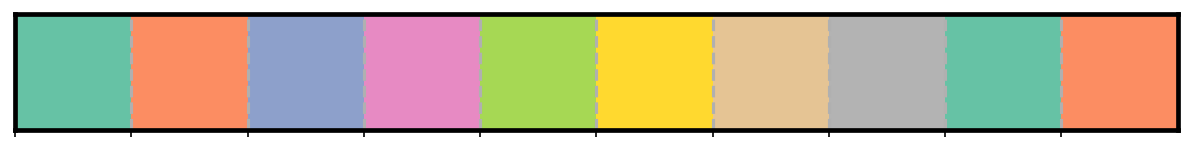

In [5]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import xarray as xr
import seaborn as sns
from scipy import stats
import cmocean
import pandas as pd
import cartopy.crs as ccrs
from matplotlib.colors import TwoSlopeNorm
def setup_plotting(ticksize=14, fontsize=20, figsize=(16, 9), dpi=150):
    """
    Global plotting setup with grey background and custom styling
    """

    # --- Figure defaults ---
    plt.rcParams.update({
        "figure.figsize": figsize,
        "figure.dpi": dpi,
    })

    # --- Background color ---
    plt.rcParams['axes.facecolor'] = "#e8e8e8"

    # --- Fonts ---
    rc = {"font.family": "serif", 
          "mathtext.fontset": "stix",
          "font.serif": ["DejaVu Serif"]}  # Better subscript support
    plt.rcParams.update(rc)
    
    plt.rcParams.update({
        "font.size": fontsize,
        "xtick.labelsize": ticksize,
        "ytick.labelsize": ticksize,
    })

    # --- Axes & ticks ---
    plt.rcParams.update({
        "axes.linewidth": 2.25,
        "axes.formatter.limits": (-1, 3),
        "axes.grid": True,
        "legend.facecolor": "white",
    })

    # --- Grid ---
    plt.rcParams.update({
        "grid.linestyle": "--",
        "grid.linewidth": 1.5,
    })

    # --- Color palette ---
    colors = sns.color_palette("Set2", 10)
    sns.set_palette(colors)
    sns.palplot(colors)
    plt.show()

    return colors




def stylize_ticks(fig, ax):
    """
    Apply inward ticks, minor ticks, and label offsets
    """

    ax.xaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, top=True)
    ax.yaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, right=True)

    ax.xaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, top=True)
    ax.yaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, right=True)

    # Label offsets
    dx = -3 / 72
    dy = -3 / 72
    x_offset = matplotlib.transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)
    y_offset = matplotlib.transforms.ScaledTranslation(0, dy, fig.dpi_scale_trans)

    for label in ax.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + y_offset)

    for label in ax.yaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + x_offset)
colors = setup_plotting(ticksize=14, fontsize=20, figsize=(16, 9), dpi=150)

In [6]:
path = "/Users/asgerthormann/Documents/uni/master/master_code/data/pressure_levels_1h/5ac7a8ea967bb32746805d2e6a302d10.nc"

ds = xr.open_dataset(path)
ds

<xarray.Dataset> Size: 26MB
Dimensions:         (valid_time: 48, pressure_level: 1, latitude: 101,
                     longitude: 221)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 384B 1999-12-03 ... 1999-12-0...
    expver          (valid_time) <U4 768B ...
  * pressure_level  (pressure_level) float64 8B 500.0
  * latitude        (latitude) float64 808B 70.0 69.75 69.5 ... 45.5 45.25 45.0
  * longitude       (longitude) float64 2kB -20.0 -19.75 -19.5 ... 34.75 35.0
    number          int64 8B ...
Data variables:
    z               (valid_time, pressure_level, latitude, longitude) float32 4MB ...
    q               (valid_time, pressure_level, latitude, longitude) float32 4MB ...
    t               (valid_time, pressure_level, latitude, longitude) float32 4MB ...
    u               (valid_time, pressure_level, latitude, longitude) float32 4MB ...
    v               (valid_time, pressure_level, latitude, longitude) float32 4MB ...
    vo              (valid_time, pressure_level, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-07T11:00 GRIB to CDM+CF via cfgrib-0.9.1...

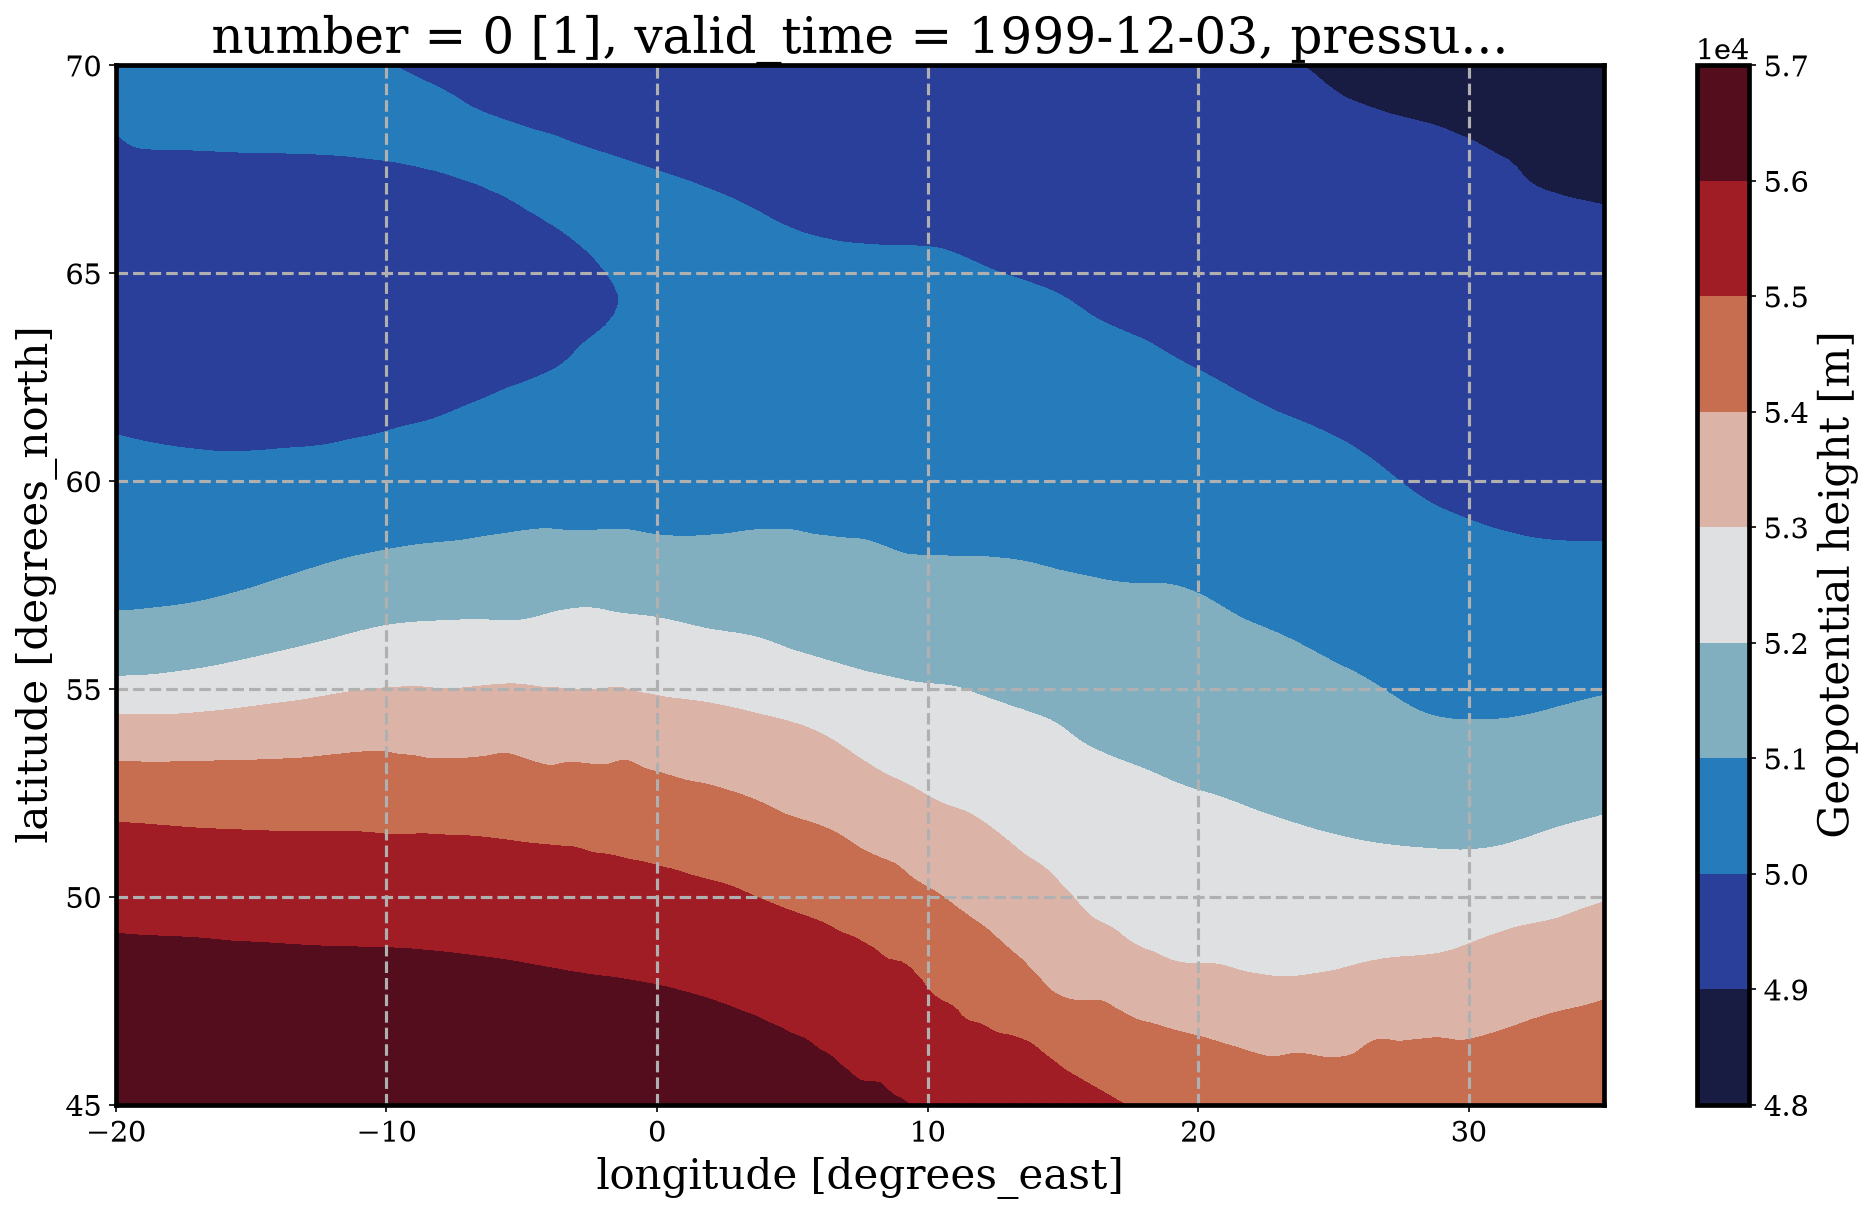

In [21]:
geo_500 = ds['z']

longitude = ds["longitude"]
latitude = ds["latitude"]
hour = ["04", "06", "08", "10", "12", "14", "16", "18", "20", "22", "00"]
day = ["1999-12-03", "1999-12-04"]

vmin = float(geo_500.min())
vmax = float(geo_500.max())
midpoint = float((vmin + vmax) / 2)

norm = TwoSlopeNorm(
    vmin=vmin,
    vcenter=midpoint,
    vmax=vmax,
)
field = geo_500.sel(valid_time="1999-12-02T04", pressure_level=500, method="nearest")
field.plot.contourf(
    cmap=cmocean.cm.balance,
    norm=norm,
    cbar_kwargs={"label": "Geopotential height [m]"},
)

/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.1

/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/asgerthormann/mamba/envs/master_env/lib/python3.1

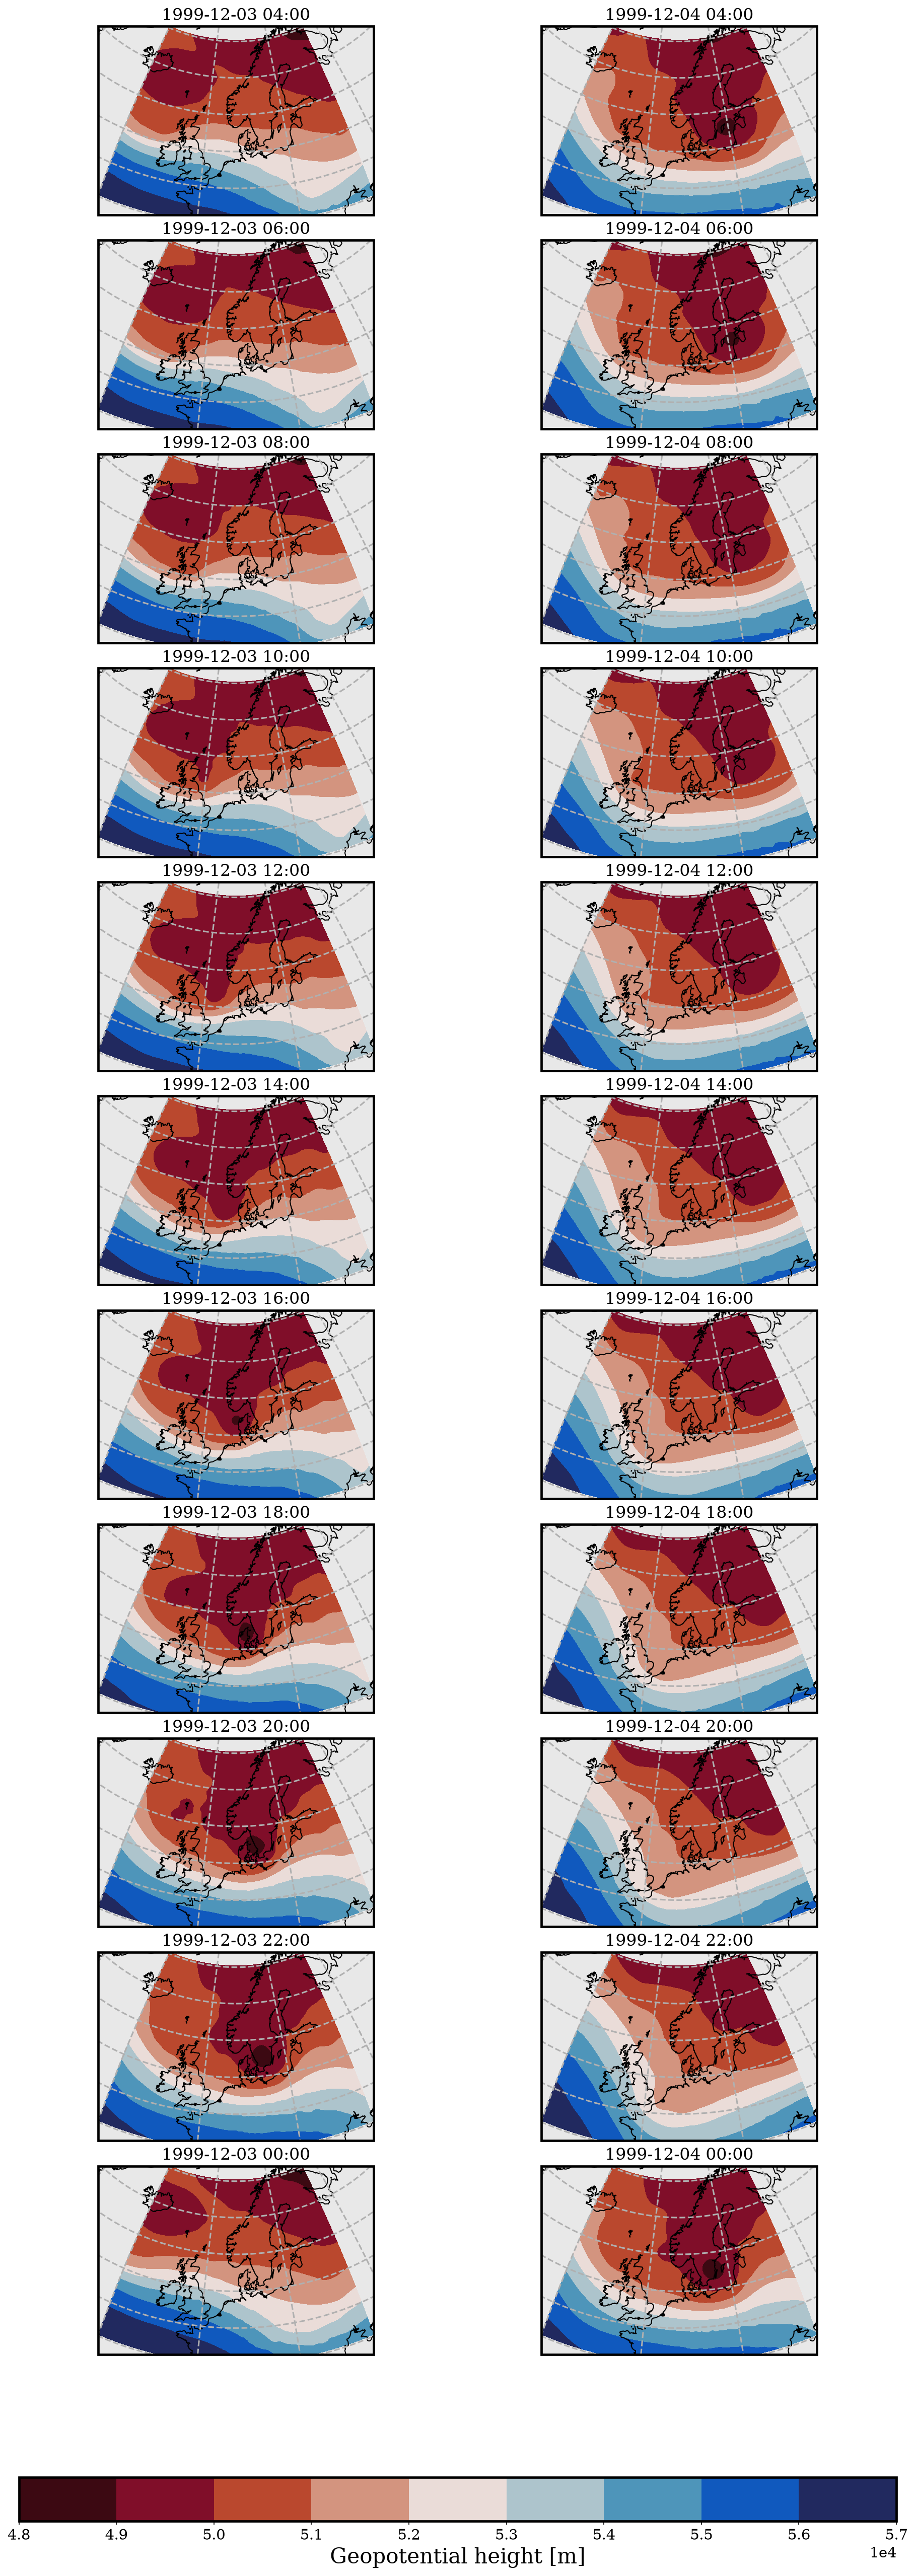

In [23]:
cols = len(day)
rows = len(hour)


fig, ax = plt.subplots(
    rows,
    cols,
    figsize=(12, 34),
    sharex=True,
    sharey=True,
    
    subplot_kw={
        "projection": ccrs.Orthographic(
            central_longitude=float(longitude.mean()),
            central_latitude=float(latitude.mean()),
        )
    },
    constrained_layout=True
)

for j, d in enumerate(day):
    for i, h in enumerate(hour):
        current_time = f"{d}T{h}"
        field = geo_500.sel(valid_time=current_time, pressure_level=500, method="nearest")
        field.plot.contourf(
            ax=ax[i, j],
            transform=ccrs.PlateCarree(),
            cmap=cmocean.cm.balance.reversed(),
            norm=norm,
            add_colorbar=False,
            
            #cbar_kwargs={"label": "Pressure"},
            
        )
        ax[i, j].coastlines()
        ax[i, j].gridlines(draw_labels=False)
        ax[i, j].set_title(f"{d} {h}:00", fontsize=16)
        ax[i, j].set_extent(
            [
        float(longitude.min()),
        float(longitude.max()),
        float(latitude.min()),
        float(latitude.max()),
             ],
    crs=ccrs.PlateCarree(),
)

fig.colorbar(ax[0, 0].collections[0], ax=ax, orientation="horizontal", fraction=0.05, pad=0.05, label="Geopotential height [m]")


        
